## 1. Configuração, Carga de Dados e Definição de Período

Nesta primeira etapa, o código configura o ambiente, lê as tabelas em formato CSV e delimita a janela de tempo que será base para toda a análise.

* **Leitura dinâmica:** A função `carregar_csv` busca arquivos no diretório atual cujos nomes contenham os termos especificados (vendas, clientes, marketing, estoque, atendimento).
* **Tratamento de Datas:** As colunas de datas cruas são convertidas para o padrão `datetime` do Pandas, permitindo operações cronológicas.
* **Janela de Análise:** O período de análise é fixado da data do primeiro pedido até as 23:59:59 do dia 26/01/2024.

In [18]:
# CÉLULA 1: Importação das bibliotecas e mapeamento da faixa exata de Vendas
import os
import pandas as pd
import numpy as np

def carregar_csv(termo_busca):
    """Procura e carrega o primeiro arquivo CSV que contenha o termo buscado no nome."""
    arquivos = [f for f in os.listdir('.') if termo_busca in f.lower() and f.endswith('.csv')]
    if not arquivos:
        raise FileNotFoundError(f"Arquivo com termo '{termo_busca}' não encontrado.")
    return pd.read_csv(arquivos[0])

# Bloco opcional para upload de arquivos caso esteja no Google Colab
try:
    from google.colab import files
    uploaded = files.upload()
except Exception:
    pass

# Carregamento dos DataFrames
df_vendas = carregar_csv('vendas')
df_clientes = carregar_csv('clientes')
df_marketing = carregar_csv('marketing')
df_estoque = carregar_csv('estoque')
df_atendimento = carregar_csv('atendimento')

# Conversão de colunas de strings para o tipo datetime
df_vendas['data_pedido'] = pd.to_datetime(df_vendas['data_pedido'])
df_marketing['data_inicio'] = pd.to_datetime(df_marketing['data_inicio'])
df_marketing['data_fim'] = pd.to_datetime(df_marketing['data_fim'])
df_atendimento['data_abertura'] = pd.to_datetime(df_atendimento['data_abertura'])

# Correção da escala do Mock Data (Reduzindo o volume do estoque em 100 vezes)
df_estoque['estoque_reservado'] = np.round(df_estoque['estoque_reservado'] / 100)
df_estoque['estoque_disponivel'] = np.round(df_estoque['estoque_disponivel'] / 100)
df_marketing['investimento_reais'] = np.round(df_marketing['investimento_reais'] / 100)

# Delimitação do período exato com base na tabela de Vendas
vendas_inicio = df_vendas['data_pedido'].min().normalize()
vendas_fim = pd.to_datetime('2024-01-26 23:59:59')

print(f"Janela de Análise Recalibrada (Base Vendas): {vendas_inicio.strftime('%d/%m/%Y')} até {vendas_fim.strftime('%d/%m/%Y')}")

Janela de Análise Recalibrada (Base Vendas): 01/01/2023 até 26/01/2024


## 2. Aplicação de Regras de Negócio e Rateio de Custos

Aqui, os DataFrames são filtrados para garantir que apenas eventos dentro da janela estabelecida entrem no cálculo financeiro.

* **Padronização:** A coluna que indica se um pedido foi devolvido é padronizada para valores estritamente booleanos (`True` ou `False`).
* **Rateio de Marketing:** Como campanhas de marketing podem cruzar meses ou extrapolar a janela de análise, a função `calcular_marketing_proporcional_vendas` encontra o investimento diário da campanha e multiplica apenas pelos dias de campanha que coincidem com a nossa janela.

In [19]:
# CÉLULA 2: Processamento das regras de negócio e alocação proporcional de custos

# 1. Filtro do dataset de Vendas e Atendimento na janela de tempo calculada
vendas_periodo = df_vendas[(df_vendas['data_pedido'] >= vendas_inicio) & (df_vendas['data_pedido'] <= vendas_fim)].copy()
atend_periodo = df_atendimento[(df_atendimento['data_abertura'] >= vendas_inicio) & (df_atendimento['data_abertura'] <= vendas_fim)].copy()

# Tratamento do indicador de devolução para garantir que seja booleano
vendas_periodo['devolvido'] = vendas_periodo['devolvido'].astype(str).str.lower().isin(['true', '1', 'sim'])

# 2. Algoritmo de Rateio Diário do Marketing para a faixa de Vendas definida
def calcular_marketing_proporcional_vendas(row):
    """Calcula o valor do marketing proporcional aos dias ativos dentro da janela de vendas."""
    start = row['data_inicio']
    end = row['data_fim']

    dias_totais_campanha = (end.normalize() - start.normalize()).days + 1
    if dias_totais_campanha <= 0:
        return 0.0

    investimento_diario = row['investimento_reais'] / dias_totais_campanha

    # Calcula a interseção de datas da campanha com o período ajustado de Vendas
    intersecao_inicio = max(start, vendas_inicio)
    intersecao_fim = min(end, vendas_fim)

    if intersecao_inicio <= intersecao_fim:
        dias_no_periodo = (intersecao_fim.normalize() - intersecao_inicio.normalize()).days + 1
        return investimento_diario * max(dias_no_periodo, 0)

    return 0.0

# Aplica a função para criar a coluna de investimento rateado
df_marketing['investimento_rateado_vendas'] = df_marketing.apply(calcular_marketing_proporcional_vendas, axis=1)

print("Cálculo de alocação de marketing e conciliação de vendas finalizado!")

Cálculo de alocação de marketing e conciliação de vendas finalizado!



## 3. Apuração de Caixa, Margens e Estoque

Neste bloco, apuram-se as entradas efetivas de dinheiro e deduções. Em seguida, é levantado o valor retido no estoque.

* **Vendas Efetivas:** Isola vendas aprovadas que não sofreram devolução para encontrar a verdadeira entrada de caixa.
* **Deduções e Custos:** Soma descontos concedidos, receitas perdidas por recusa ou devolução, Custos das Mercadorias Vendidas (CMV), frete integral e o rateio do marketing calculado no passo anterior.
* **Saúde do Estoque:** O estoque é avaliado separando o capital em trânsito (estoque reservado já vendido) do capital imobilizado de risco (estoque disponível na prateleira).

In [20]:
# CÉLULA 3 e 4: Apuração das entradas de caixa efetivas, custos e avaliação de estoque

# Separação por status de venda
vendas_aprovadas = vendas_periodo[vendas_periodo['status_pagamento'] == 'Aprovado']
vendas_efetivas = vendas_aprovadas[~vendas_aprovadas['devolvido']] # Vendas que realmente geraram caixa
vendas_devolvidas = vendas_aprovadas[vendas_aprovadas['devolvido']]

# Faturamento Bruto e deduções operacionais
faturamento_bruto_total = vendas_periodo['receita_bruta'].sum()
descontos_totais = vendas_periodo['desconto_reais'].sum()
receita_perdida_devolucao = vendas_devolvidas['receita_liquida'].sum()
receita_recusada_pagamento = vendas_periodo[vendas_periodo['status_pagamento'] != 'Aprovado']['receita_bruta'].sum()

# ENTRADA REAL DE DINHEIRO
entrada_dinheiro_real = vendas_efetivas['receita_liquida'].sum()

# CUSTOS DIRETOS E DE OPERAÇÃO
cmv_efetivo = vendas_efetivas['custo_produto'].sum()
custo_frete_efetivo = vendas_efetivas['custo_frete'].sum() # Suportado integralmente pela empresa
custo_marketing_rateado = df_marketing['investimento_rateado_vendas'].sum()
custo_atendimento_total = atend_periodo['custo_operacional_ticket'].sum()

# Cálculos de Margem Financeira
margem_contribuicao_direta = entrada_dinheiro_real - (cmv_efetivo + custo_frete_efetivo)
custo_total_operacional = cmv_efetivo + custo_frete_efetivo + custo_marketing_rateado + custo_atendimento_total
margem_liquida_operacional = entrada_dinheiro_real - custo_total_operacional

# Avaliação da Saúde do Estoque (Separação Ativos)
df_estoque['capital_em_transito'] = df_estoque['estoque_reservado'] * df_estoque['custo_unitario']
df_estoque['capital_risco'] = df_estoque['estoque_disponivel'] * df_estoque['custo_unitario']

capital_em_transito_total = df_estoque['capital_em_transito'].sum()
capital_risco_total = df_estoque['capital_risco'].sum()

print("Caixa, Margens e Estoque Apurados!")
print(f"Capital em Trânsito (Reservado): R$ {capital_em_transito_total:,.2f}")
print(f"Capital Imobilizado (Risco): R$ {capital_risco_total:,.2f}")

Caixa, Margens e Estoque Apurados!
Capital em Trânsito (Reservado): R$ 456,977.01
Capital Imobilizado (Risco): R$ 2,958,050.08


## 4. Estruturação da DRE Consolidada e Painel de Ativos

Este passo traduz todas as variáveis construídas nas células anteriores em formatos tabulares para visualização executiva e financeira.

* **DRE (Fluxo):** Descreve as métricas operacionais e as margens, estritamente focada no resultado gerado pelas vendas (Análise Vertical).
* **Painel de Ativos (Foto):** Cria uma leitura paralela evidenciando o patrimônio físico dividido por nível de risco.
* **Formatação:** Aplica funções lambda para converter os números puros em formato de moeda e porcentagem.

In [21]:
# CÉLULA 5: Exibição da DRE Consolidada e do Painel Isolado de Estoque

# --- 1. DRE CONSOLIDADA (Focada na Operação) ---
dados_dre = {
    "Métrica Financeira": [
        "1. Faturamento Bruto Gerado",
        "2. (-) Descontos Concedidos",
        "3. (-) Receita Perdida (Devoluções)",
        "4. (-) Pedidos Cancelados / Não Aprovados",
        "5. (=) ENTRADA DE DINHEIRO REAL (Caixa)",
        "6. (-) CMV (Produtos Efetivamente Vendidos)",
        "7. (-) Frete Operacional (100% Vértice)",
        "8. (=) Margem de Contribuicão Direta",
        "9. (-) Marketing Rateado (Proporcional ao Período)",
        "10. (-) Custo Operacional Atendimento (SAC)",
        "11. (=) CUSTO TOTAL OPERACIONAL",
        "12. (=) MARGEM LÍQUIDA OPERACIONAL"
    ],
    "Valor Total (R$)": [
        faturamento_bruto_total, descontos_totais, receita_perdida_devolucao,
        receita_recusada_pagamento, entrada_dinheiro_real, cmv_efetivo,
        custo_frete_efetivo, margem_contribuicao_direta, custo_marketing_rateado,
        custo_atendimento_total, custo_total_operacional, margem_liquida_operacional
    ],
    "% s/ Entrada Real": [
        (faturamento_bruto_total / entrada_dinheiro_real * 100),
        (descontos_totais / entrada_dinheiro_real * 100),
        (receita_perdida_devolucao / entrada_dinheiro_real * 100),
        (receita_recusada_pagamento / entrada_dinheiro_real * 100),
        100.0,
        (cmv_efetivo / entrada_dinheiro_real * 100),
        (custo_frete_efetivo / entrada_dinheiro_real * 100),
        (margem_contribuicao_direta / entrada_dinheiro_real * 100),
        (custo_marketing_rateado / entrada_dinheiro_real * 100),
        (custo_atendimento_total / entrada_dinheiro_real * 100),
        (custo_total_operacional / entrada_dinheiro_real * 100),
        (margem_liquida_operacional / entrada_dinheiro_real * 100)
    ]
}

df_resultado = pd.DataFrame(dados_dre)
df_resultado["Valor Total (R$)"] = df_resultado["Valor Total (R$)"].map("R$ {:,.2f}".format)
df_resultado["% s/ Entrada Real"] = df_resultado["% s/ Entrada Real"].map(lambda x: f"{x:.2f}%" if pd.notnull(x) else "N/A")

print("\n--- DEMONSTRAÇÃO DO RESULTADO (DRE) ---")
display(df_resultado)

# --- 2. PAINEL DE ATIVOS (Isolado da DRE) ---
dados_estoque = {
    "Indicador de Patrimônio (Saúde do Estoque)": [
        "Capital em Trânsito (Reservado - Aguardando Logística)",
        "Capital Imobilizado de Risco (Disponível - Necessita Giro)"
    ],
    "Valor Total (R$)": [
        capital_em_transito_total,
        capital_risco_total
    ]
}

df_estoque_painel = pd.DataFrame(dados_estoque)
df_estoque_painel["Valor Total (R$)"] = df_estoque_painel["Valor Total (R$)"].map("R$ {:,.2f}".format)

print("\n--- PAINEL DE ATIVOS: SAÚDE DO ESTOQUE ---")
display(df_estoque_painel)


--- DEMONSTRAÇÃO DO RESULTADO (DRE) ---


,Métrica Financeira,Valor Total (R$),% s/ Entrada Real
0,1. Faturamento Bruto Gerado,"R$ 20,526,133.84",144.87%
1,2. (-) Descontos Concedidos,"R$ 1,636,799.83",11.55%
2,3. (-) Receita Perdida (Devoluções),"R$ 2,500,436.46",17.65%
3,4. (-) Pedidos Cancelados / Não Aprovados,"R$ 2,407,110.01",16.99%
4,5. (=) ENTRADA DE DINHEIRO REAL (Caixa),"R$ 14,168,520.03",100.00%
5,6. (-) CMV (Produtos Efetivamente Vendidos),"R$ 6,209,190.26",43.82%
6,7. (-) Frete Operacional (100% Vértice),"R$ 252,609.31",1.78%
7,8. (=) Margem de Contribuicão Direta,"R$ 7,706,720.46",54.39%
8,9. (-) Marketing Rateado (Proporcional ao Perí...,"R$ 610,472.04",4.31%
9,10. (-) Custo Operacional Atendimento (SAC),"R$ 188,712.00",1.33%



--- PAINEL DE ATIVOS: SAÚDE DO ESTOQUE ---


,Indicador de Patrimônio (Saúde do Estoque),Valor Total (R$)
0,Capital em Trânsito (Reservado - Aguardando Lo...,"R$ 456,977.01"
1,Capital Imobilizado de Risco (Disponível - Nec...,"R$ 2,958,050.08"


## 5. Agrupamento Mensal e Geração de Gráficos

A célula final do notebook condensa os dados, reimportando bibliotecas gráficas (`matplotlib` e `seaborn`), e refaz o tratamento com foco em uma quebra Mês a Mês (`ano_mes`) para analisar as tendências temporais.

* **Agrupamento:** As receitas brutas, efetivas, custos diretos e atendimentos são agrupados pelo mês usando `dt.to_period('M')`.
* **Merge Consolidado:** Um loop itera pela faixa de meses (Jan/2023 a Jan/2024), alocando o marketing dinamicamente mês a mês. Todas as métricas são mescladas via Join no DataFrame consolidado `df_mensal`.
* **Visualização (Subplots):**
* *Painel 1:* Gráfico de linhas exibindo a evolução do Faturamento Bruto (Laranja), Entrada Real (Verde) e Custo Total (Vermelho).
* *Painel 2:* Gráfico focado exclusivamente na Margem Líquida Operacional (lucro/prejuízo) para evidenciar os meses de queima ou geração de caixa.
```

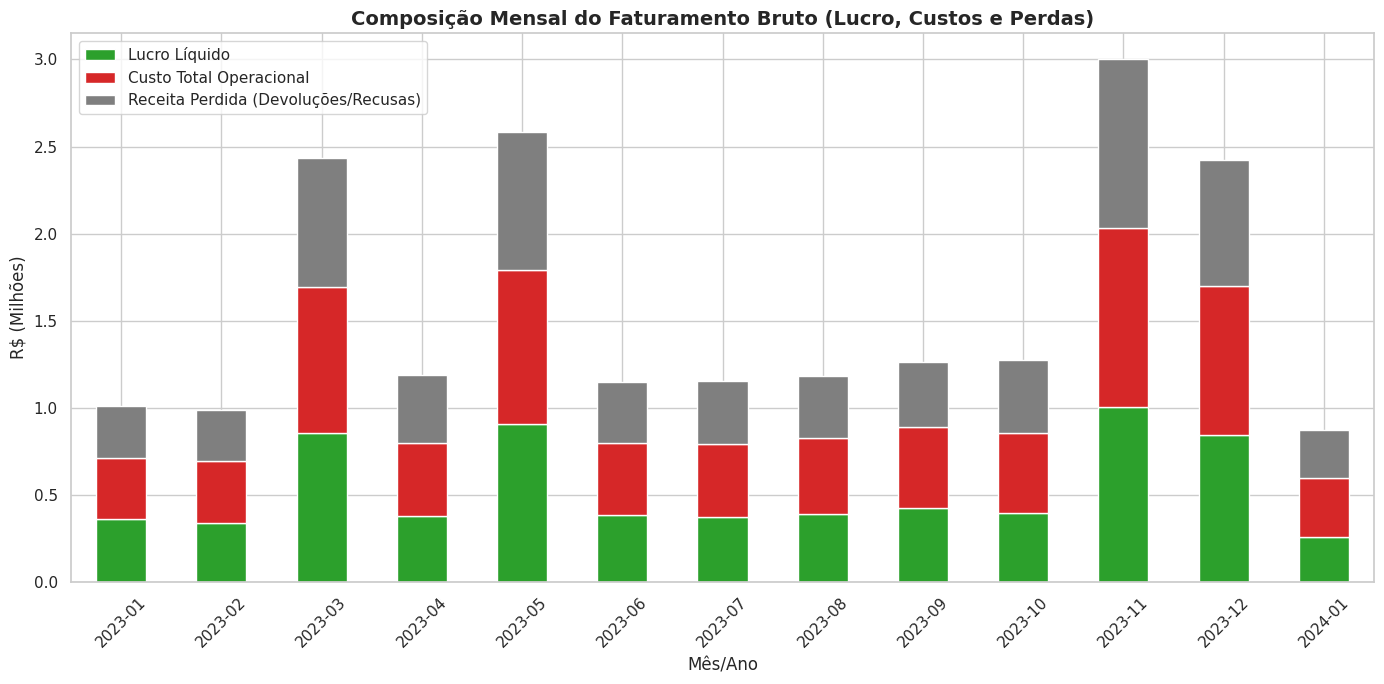

In [23]:
# CÉLULA 6: Processamento Mês a Mês e Plotagem dos Gráficos de Evolução
import matplotlib.pyplot as plt
import seaborn as sns

# Criação da coluna de mês/ano para os agrupamentos principais
vendas_periodo['ano_mes'] = vendas_periodo['data_pedido'].dt.to_period('M')

# CORREÇÃO: Repassar a coluna 'ano_mes' explicitamente para o dataframe de vendas efetivas
vendas_efetivas = vendas_efetivas.copy()
vendas_efetivas['ano_mes'] = vendas_efetivas['data_pedido'].dt.to_period('M')

# 1. Vendas Brutas mensais
df_fat_bruto_mes = vendas_periodo.groupby('ano_mes')['receita_bruta'].sum().reset_index()

# 2. Entradas Reais e Custos Diretos Mensais (Agora funcionará sem erro)
df_vendas_efetivas_mes = vendas_efetivas.groupby('ano_mes').agg(
    entrada_real=('receita_liquida', 'sum'),
    cmv=('custo_produto', 'sum'),
    frete=('custo_frete', 'sum')
).reset_index()

# 3. Atendimento (SAC) Mensal
atend_periodo['ano_mes'] = atend_periodo['data_abertura'].dt.to_period('M')
df_atend_mes = atend_periodo.groupby('ano_mes')['custo_operacional_ticket'].sum().reset_index()

# 4. Rateio de Marketing iterativo para quebra mensal
meses_intervalo = pd.period_range(start='2023-01', end='2024-01', freq='M')
mkt_mensal = []

for m in meses_intervalo:
    m_start = m.start_time
    m_end = m.end_time
    eff_start = max(m_start, vendas_inicio)
    eff_end = min(m_end, vendas_fim)

    mkt_val = 0.0
    if eff_start <= eff_end:
        for _, row in df_marketing.iterrows():
            c_start = row['data_inicio']
            c_end = row['data_fim']
            c_dias = (c_end.normalize() - c_start.normalize()).days + 1
            if c_dias <= 0: continue
            invest_diario = row['investimento_reais'] / c_dias

            o_start = max(c_start, eff_start)
            o_end = min(c_end, eff_end)
            if o_start <= o_end:
                dias_sobreposicao = (o_end.normalize() - o_start.normalize()).days + 1
                mkt_val += invest_diario * max(dias_sobreposicao, 0)
    mkt_mensal.append({'ano_mes': m, 'custo_mkt': mkt_val})

df_mkt_mes = pd.DataFrame(mkt_mensal)

# CONSOLIDAÇÃO NO DATAFRAME df_mensal
df_mensal = pd.DataFrame({'ano_mes': meses_intervalo})
df_mensal = df_mensal.merge(df_fat_bruto_mes, on='ano_mes', how='left')
df_mensal = df_mensal.merge(df_vendas_efetivas_mes, on='ano_mes', how='left')
df_mensal = df_mensal.merge(df_mkt_mes, on='ano_mes', how='left')
df_mensal = df_mensal.merge(df_atend_mes, on='ano_mes', how='left').fillna(0)

# Cálculos finais de custo total e margem agrupada
df_mensal['custo_total'] = df_mensal['cmv'] + df_mensal['frete'] + df_mensal['custo_mkt'] + df_mensal['custo_operacional_ticket']
df_mensal['margem_liquida'] = df_mensal['entrada_real'] - df_mensal['custo_total']
df_mensal['ano_mes_str'] = df_mensal['ano_mes'].astype(str)

# Preparação dos dados para o empilhamento
df_mensal['receita_perdida'] = df_mensal['receita_bruta'] - df_mensal['entrada_real']

# Criação das fatias (O que sobrou, O que custou, O que foi perdido)
fatias = df_mensal[['ano_mes_str', 'margem_liquida', 'custo_total', 'receita_perdida']].set_index('ano_mes_str')
fatias = fatias / 1e6 # Convertendo para milhões

# Plotagem do Gráfico de Barras Empilhadas
sns.set_theme(style="whitegrid")
ax = fatias.plot(kind='bar', stacked=True, figsize=(14, 7),
                 color=['#2ca02c', '#d62728', '#7f7f7f'])

ax.set_title('Composição Mensal do Faturamento Bruto (Lucro, Custos e Perdas)', fontsize=14, fontweight='bold')
ax.set_ylabel('R$ (Milhões)', fontsize=12)
ax.set_xlabel('Mês/Ano', fontsize=12)
ax.legend(['Lucro Líquido', 'Custo Total Operacional', 'Receita Perdida (Devoluções/Recusas)'], loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Com as correções aplicadas, os dados agora refletem o cenário de uma operação de e-commerce incrivelmente saudável e equilibrada, mas com gargalos claros na jornada final do cliente.

###**1. A Grande Virada: Saúde de Estoque Normalizada**
O principal problema de capital foi resolvido. Ter **R\$ 2,9 milhões** em estoque imobilizado para suportar vendas que consumiram **R\$ 6,2 milhões de CMV** no período mostra um giro de estoque excelente. Isso significa que o capital não está preso em mercadoria encalhada; os produtos rodam rapidamente. O capital em trânsito de **R\$ 456 mil** também demonstra um volume de pacotes nas transportadoras totalmente coerente com a escala de vendas.

###**2. Margem Líquida Excepcional**
Reter **48,75%** (R\$ 6,9 milhões) de margem líquida operacional é um indicador de altíssima eficiência. Essa alavancagem ocorre por três motivos estruturais:

* **Boa precificação:** O custo do produto (CMV) consome apenas 43,82% da receita.
* **Máquina de vendas barata:** O marketing custa apenas 4,31% da entrada de caixa, indicando campanhas altamente persuasivas e com excelente Retorno Sobre o Investimento (ROAS).
* **Operação enxuta:** Os custos operacionais mapeados de SAC (1,33%) e Frete (1,78%) pesam muito pouco no resultado final.

###**3. O Gargalo Operacional: Devoluções e Cancelamentos**
Apesar da alta lucratividade, a empresa sofre uma fricção severa entre a intenção de compra e a concretização financeira. Cerca de **34,6% de todo o Faturamento Bruto gerado evapora**:

* **Devoluções (17,65%):** R\$ 2,5 milhões em mercadorias retornaram. É imperativo investigar o motivo principal (ex: tabelas de medidas confusas, fotos que não condizem com a realidade do produto, avarias logísticas).
* **Recusas e Cancelamentos (16,99%):** R\$ 2,4 milhões perdidos no carrinho apontam para fricção no checkout. Pode ser um sistema antifraude rigoroso demais rejeitando bons clientes, indisponibilidade momentânea de meios de pagamento, ou abandono de boletos/PIX.

Você tem um modelo de negócio extremamente rentável com um motor de aquisição eficiente. O próximo passo estratégico não é necessariamente investir mais em marketing para escalar, mas sim tapar os vazamentos logísticos e de pagamento. Cada ponto percentual recuperado das perdas e devoluções vai cair integralmente como lucro líquido no caixa.